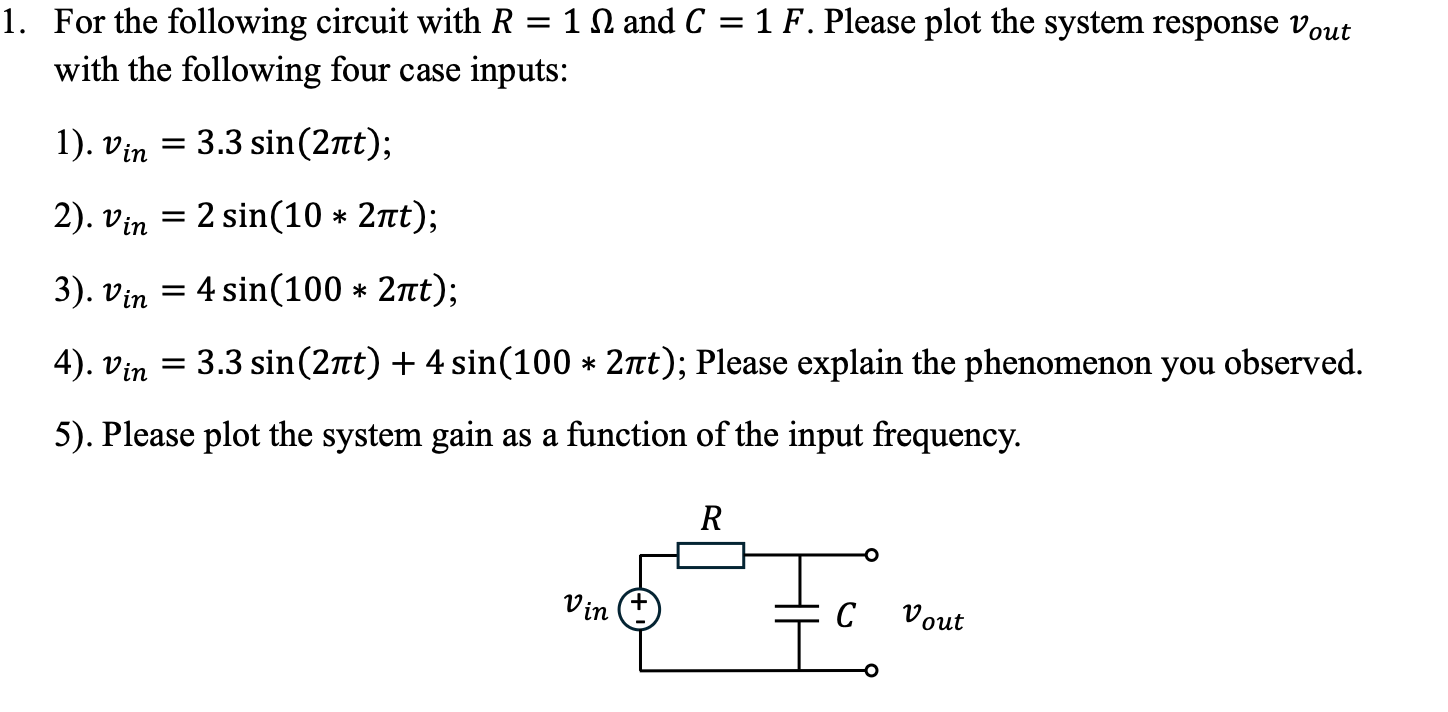

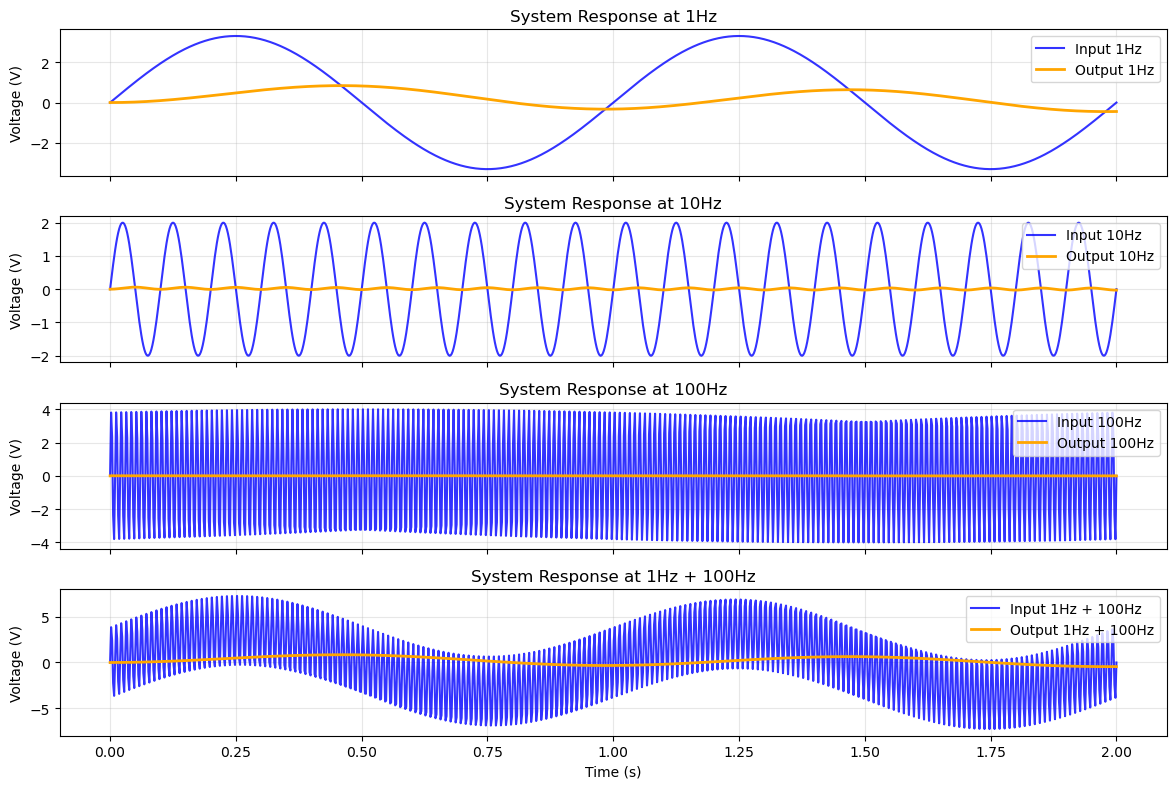

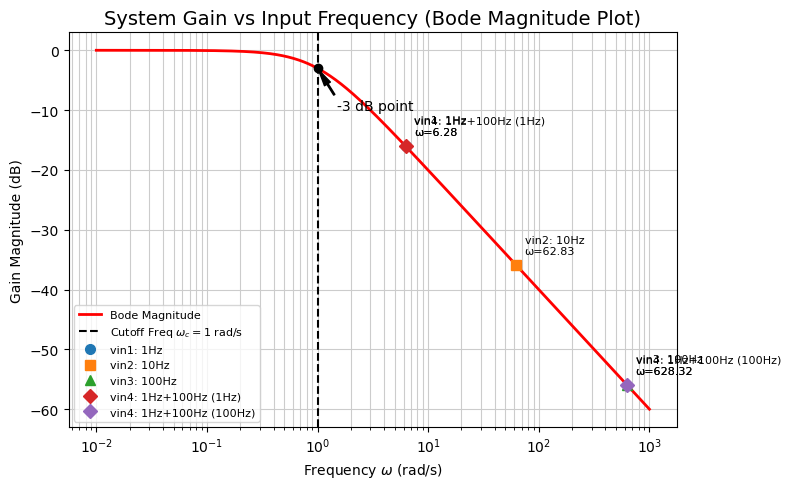

In [22]:
from numpy import sqrt, mean, std,pi,sin,linspace
import matplotlib.pyplot as plt
import pandas as pd 

R = 1 #omh
C = 1 #F
t = linspace(0,2,1000)
vin1 = 3.3 * sin(2*pi*1*t) #1Hz
vin2 = 2 * sin(2*pi*10*t) #10Hz
vin3 = 4 * sin(2*pi*100*t) #100Hz
vin4 =  vin1 + vin3
# plot the system reponse
# RC 低通系统: H(s) = 1 / (RCs + 1)
num = [1]
den = [R * C, 1]
system = signal.TransferFunction(num, den)

# 更简洁：用循环统一计算与绘图
inputs = [vin1, vin2, vin3, vin4]
labels = ["1Hz", "10Hz", "100Hz", "1Hz + 100Hz"]

# 计算输出
outputs = [signal.lsim(system, U=vin, T=t)[1] for vin in inputs]
vout1, vout2, vout3, vout4 = outputs  # 保留原变量名，便于后续使用

# 绘图
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for ax, vin, vout, label in zip(axes, inputs, outputs, labels):
    ax.plot(t, vin, label=f"Input {label}", color="blue", alpha=0.8)
    ax.plot(t, vout, label=f"Output {label}", color="orange", linewidth=2)
    ax.set_title(f"System Response at {label}")
    ax.set_ylabel("Voltage (V)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

#plot the system gain 用 bode plot
w, mag, phase = signal.bode(system, w=np.logspace(-2, 3, 500))  # 频率范围从0.1Hz到1000Hz

# 绘制增益图
fig2, ax_gain = plt.subplots(figsize=(8, 5))
ax_gain.plot(w, mag, color='red', linewidth=2, label='Bode Magnitude')
ax_gain.set_xscale('log')  # X轴使用对数坐标
ax_gain.set_title('System Gain vs Input Frequency (Bode Magnitude Plot)', fontsize=14)
ax_gain.set_xlabel('Frequency $\omega$ (rad/s)')
ax_gain.set_ylabel('Gain Magnitude (dB)')
ax_gain.grid(True, which="both", ls="-", color='0.8')

# 标注截止频率 (Cutoff Frequency, wc = 1/RC = 1 rad/s)
ax_gain.axvline(x=1, color='k', linestyle='--', label='Cutoff Freq $\omega_c = 1$ rad/s')
ax_gain.plot(1, -3.01, 'ko')  # -3dB 点
ax_gain.annotate('-3 dB point', xy=(1, -3.01), xytext=(1.5, -10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# 在曲线上标示每一种输入情况对应的频率
# 注意：Bode 图频率单位是 rad/s，需由 Hz 转为 ω=2πf
case_freqs = [
    ("vin1: 1Hz", 1, "o", 7),
    ("vin2: 10Hz", 10, "s", 7),
    ("vin3: 100Hz", 100, "^", 7),
    ("vin4: 1Hz+100Hz (1Hz)", 1, "D", 7),
    ("vin4: 1Hz+100Hz (100Hz)", 100, "D", 7),
]

for label, f_hz, marker, markersize in case_freqs:
    omega = 2 * pi * f_hz
    idx = np.argmin(np.abs(w - omega))
    w_mark, mag_mark = w[idx], mag[idx]
    ax_gain.plot(w_mark, mag_mark, marker=marker, markersize=markersize, linestyle='None', label=label)
    ax_gain.annotate(
        f"{label}\nω={omega:.2f}",
        xy=(w_mark, mag_mark),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=8
    )

ax_gain.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()


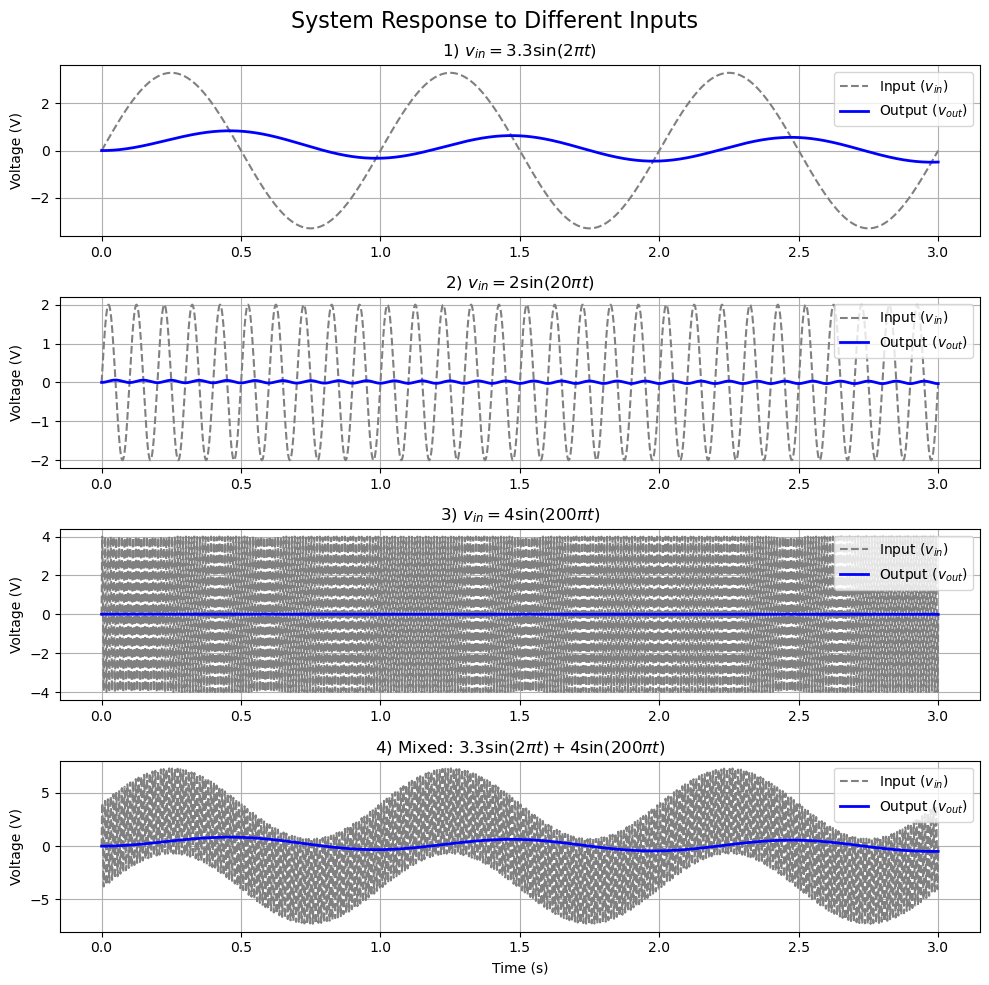

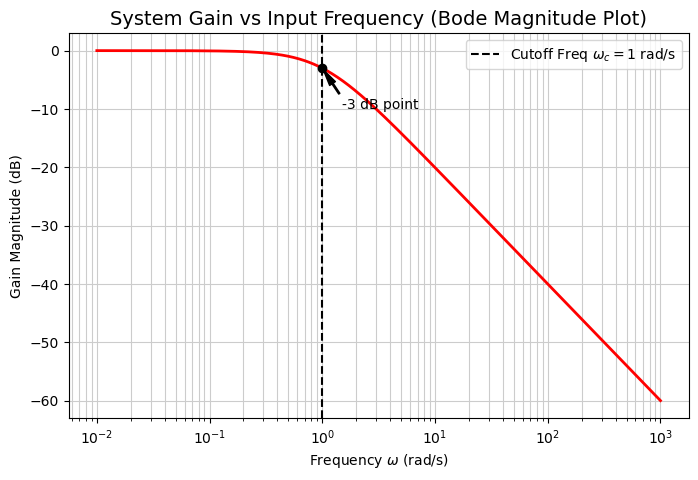

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 0. 定义系统模型 H(s) = 1 / (RCs + 1)
# ==========================================
R = 1.0  # Ohms
C = 1.0  # Farads
num = [1]          # 分子系数
den = [R*C, 1]     # 分母系数 (s + 1)
system = signal.TransferFunction(num, den)

# ==========================================
# 1-4. 时域仿真 (Time Domain Response)
# ==========================================
# 设置时间向量 t，从 0 到 3 秒，步长极小以捕获 100Hz 的高频信号
t = np.linspace(0, 3, 5000)

# 定义四种输入信号
v_in1 = 3.3 * np.sin(2 * np.pi * t)
v_in2 = 2.0 * np.sin(10 * 2 * np.pi * t)
v_in3 = 4.0 * np.sin(100 * 2 * np.pi * t)
v_in4 = v_in1 + v_in3

inputs = [v_in1, v_in2, v_in3, v_in4]
titles = [
    '1) $v_{in} = 3.3 \sin(2\pi t)$',
    '2) $v_{in} = 2 \sin(20\pi t)$',
    '3) $v_{in} = 4 \sin(200\pi t)$',
    '4) Mixed: $3.3 \sin(2\pi t) + 4 \sin(200\pi t)$'
]

# 绘制时域图
fig1, axs = plt.subplots(4, 1, figsize=(10, 10))
fig1.suptitle('System Response to Different Inputs', fontsize=16)

for i in range(4):
    # 使用 lsim (Linear simulation) 计算系统对任意输入的响应
    _, v_out, _ = signal.lsim(system, U=inputs[i], T=t)
    
    axs[i].plot(t, inputs[i], label='Input ($v_{in}$)', color='gray', linestyle='--')
    axs[i].plot(t, v_out, label='Output ($v_{out}$)', color='blue', linewidth=2)
    axs[i].set_title(titles[i])
    axs[i].set_ylabel('Voltage (V)')
    axs[i].grid(True)
    axs[i].legend(loc='upper right')

axs[3].set_xlabel('Time (s)')
plt.tight_layout()

# ==========================================
# 5. 频域增益图 (Frequency Domain - Bode Plot)
# ==========================================
# 生成角频率向量 w (从 10^-2 到 10^3 rad/s)
w = np.logspace(-2, 3, 500)

# 使用 bode 函数计算频率响应
w, mag, phase = signal.bode(system, w)

# 绘制增益图
fig2, ax_gain = plt.subplots(figsize=(8, 5))
ax_gain.plot(w, mag, color='red', linewidth=2)
ax_gain.set_xscale('log')  # X轴使用对数坐标
ax_gain.set_title('System Gain vs Input Frequency (Bode Magnitude Plot)', fontsize=14)
ax_gain.set_xlabel('Frequency $\omega$ (rad/s)')
ax_gain.set_ylabel('Gain Magnitude (dB)')
ax_gain.grid(True, which="both", ls="-", color='0.8')

# 标注截止频率 (Cutoff Frequency, wc = 1/RC = 1 rad/s)
ax_gain.axvline(x=1, color='k', linestyle='--', label='Cutoff Freq $\omega_c = 1$ rad/s')
ax_gain.plot(1, -3.01, 'ko')  # -3dB 点
ax_gain.annotate('-3 dB point', xy=(1, -3.01), xytext=(1.5, -10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
ax_gain.legend()

plt.show()

# Problem 2


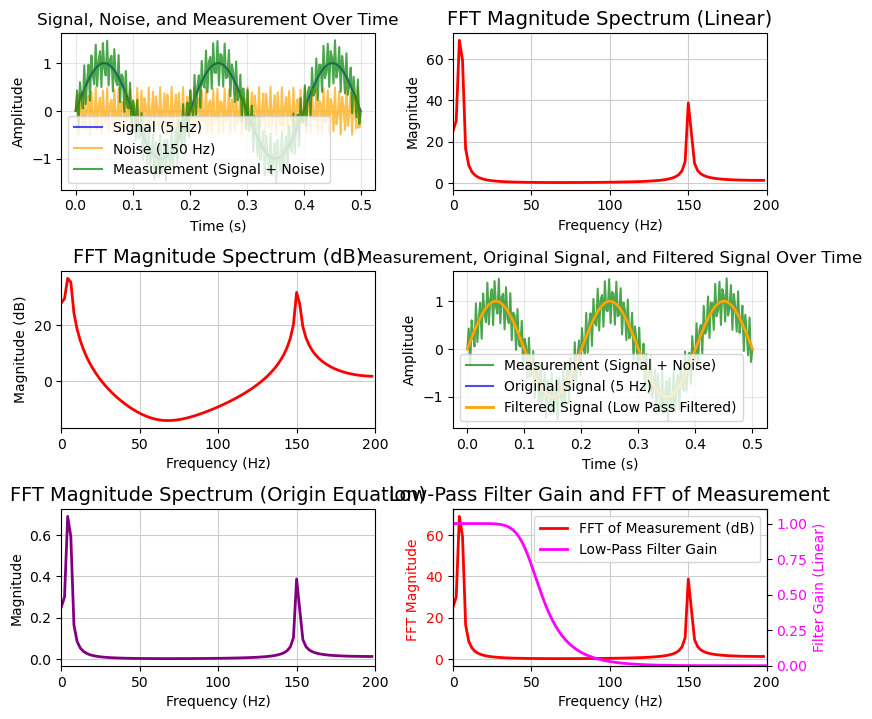

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
sample_rate = 400
N = 200 # Number of sample points
T = 1 / sample_rate # sample spacing
t = np.linspace(0.0, N*T, N)
f1 = 5
f2 = 150
signal_input = np.sin(f1 * 2.0*np.pi*t)
noise = 0.5*np.sin(f2 * 2.0*np.pi*t)
measurement = signal_input+noise
# plot signal and noise and measurement
plt.figure(figsize=(8, 14))
plt.subplot(6, 2, 1)
plt.plot(t, signal_input, label='Signal (5 Hz)', color='blue', alpha=0.7)
plt.plot(t, noise, label='Noise (150 Hz)', color='orange', alpha=0.7)
plt.plot(t, measurement, label='Measurement (Signal + Noise)', color='green', alpha=0.7)
plt.title('Signal, Noise, and Measurement Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# do a FFT analysis and get the frequency response (magnitude and phase) of the system to the input signal.
fft_result = np.fft.fft(measurement)
fft_freq = np.fft.fftfreq(N, T)
fft_magnitude = np.abs(fft_result)
fft_phase = np.angle(fft_result)
fft_freq_positive = fft_freq[:N//2]
fft_magnitude_positive = fft_magnitude[:N//2]
fft_phase_positive = fft_phase[:N//2]
#plot FFT result in Linear and dB scale
plt.subplot(6, 2, 2)
plt.plot(fft_freq_positive, fft_magnitude_positive, color='red', linewidth=2)
plt.title('FFT Magnitude Spectrum (Linear)', fontsize=14)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, which="both", ls="-", color='0.8')
plt.xlim(0, sample_rate/2)
plt.subplot(6, 2, 3)
plt.plot(fft_freq_positive, 20 * np.log10(fft_magnitude_positive), color='red', linewidth=2)
plt.title('FFT Magnitude Spectrum (dB)', fontsize=14)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", ls="-", color='0.8')
plt.xlim(0, sample_rate/2)
plt.tight_layout()
# plot the measurement, the signal and the result after low pass filter
# apply low pass filter (cutoff frequency = 50 Hz)
cutoff_freq = 50  # Hz
b, a = signal.butter(4, cutoff_freq / (0.5 * sample_rate), btype='low')
filtered_signal = signal.filtfilt(b, a, measurement)
plt.subplot(6, 2, 4)
plt.plot(t, measurement, label='Measurement (Signal + Noise)', color='green', alpha=0.7)
plt.plot(t, signal_input, label='Original Signal (5 Hz)', color='blue', alpha=0.7)
plt.plot(t, filtered_signal, label='Filtered Signal (Low Pass Filtered)', color='orange', linewidth=2)
plt.title('Measurement, Original Signal, and Filtered Signal Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
#Do FFT with origin equation and plot the result (do not use the built-in FFT function)
def origin_fft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X
fft_result_origin = origin_fft(measurement)
fft_freq_magnitude_origin = np.abs(fft_result_origin)*2/N
# plot the result
plt.subplot(6, 2, 5)
plt.plot(fft_freq_positive, fft_freq_magnitude_origin[:N//2], color='purple', linewidth=2)
plt.title('FFT Magnitude Spectrum (Origin Equation)', fontsize=14)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, which="both", ls="-", color='0.8')
plt.xlim(0, sample_rate/2)
plt.tight_layout()
# plot the gain of the low-pass filter as well as the FFT of the measurement 
w, h = signal.freqz(b, a, worN=512, fs=sample_rate)
ax1 = plt.subplot(6, 2, 6)

# 左轴：measurement 的 FFT（dB）
line1, = ax1.plot(
    fft_freq_positive,
    fft_magnitude_positive,
    color='red',
    linewidth=2,
    label='FFT of Measurement (dB)'
)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('FFT Magnitude ', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlim(0, sample_rate / 2)
ax1.grid(True, which="both", ls="-", color='0.8')

# 右轴：低通滤波器增益（线性）
ax2 = ax1.twinx()
line2, = ax2.plot(
    w,
    np.abs(h),
    color='magenta',
    linewidth=2,
    label='Low-Pass Filter Gain'
)
ax2.set_ylabel('Filter Gain (Linear)', color='magenta')
ax2.tick_params(axis='y', labelcolor='magenta')
ax2.set_ylim(0, 1.1)

ax1.set_title('Low-Pass Filter Gain and FFT of Measurement', fontsize=14)

# 合并图例
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

# Problem 3
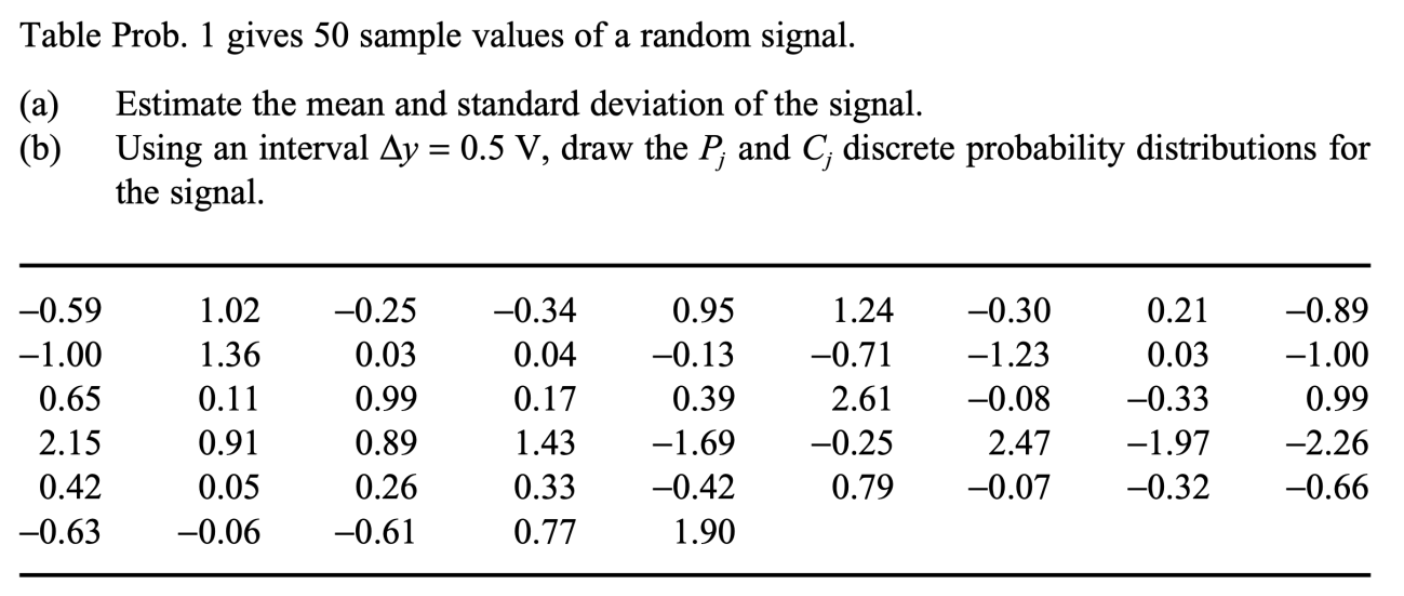

Mean: 0.1474
Standard Deviation: 1.0218


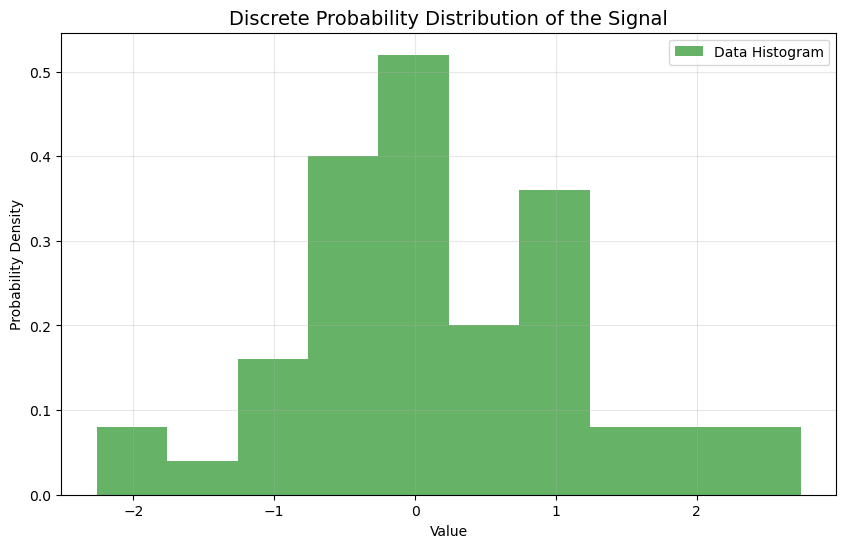

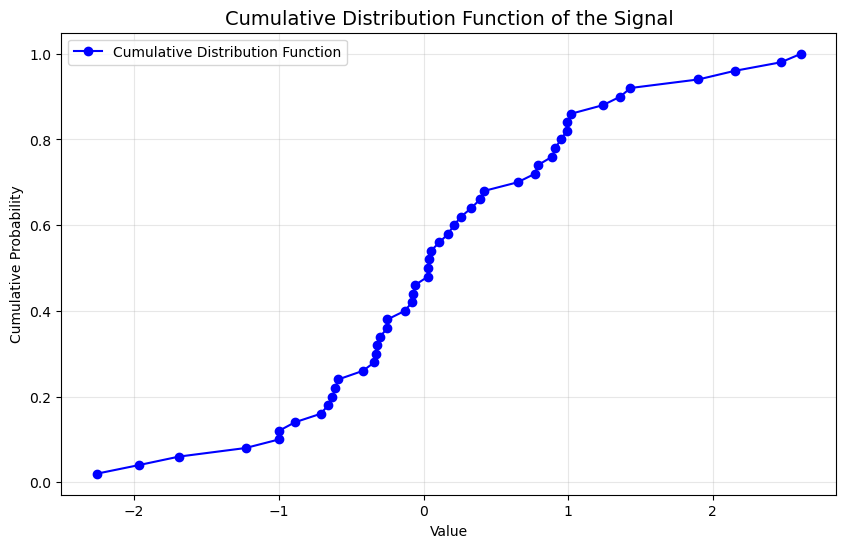

In [35]:
from numpy import mean, std
Dataset = [-0.59, 1.02, -0.25, -0.34, 0.95, 1.24, -0.30, 0.21, -0.89,
    -1.00, 1.36, 0.03, 0.04, -0.13, -0.71, -1.23, 0.03, -1.00,
    0.65, 0.11, 0.99, 0.17, 0.39, 2.61, -0.08, -0.33, 0.99,
    2.15, 0.91, 0.89, 1.43, -1.69, -0.25, 2.47, -1.97, -2.26,
    0.42, 0.05, 0.26, 0.33, -0.42, 0.79, -0.07, -0.32, -0.66,
    -0.63, -0.06, -0.61, 0.77, 1.90]
mean_value = mean(Dataset)
std_value = std(Dataset)
print(f"Mean: {mean_value:.4f}")
print(f"Standard Deviation: {std_value:.4f}")
#interval delta_y = 0.5v draw P_j and C_j discrete probability distribution for the signal
delta_y = 0.5
bins = np.arange(min(Dataset), max(Dataset) + delta_y, delta_y)
plt.figure(figsize=(10, 6))
plt.hist(Dataset, bins=bins, density=True, alpha=0.6, color='g', label='Data Histogram')
plt.title('Discrete Probability Distribution of the Signal', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# cumilative distribution function
sorted_data = np.sort(Dataset)
cumulative_prob = np.arange(1, len(Dataset) + 1) / len(Dataset)
plt.figure(figsize=(10, 6))
plt.plot(sorted_data, cumulative_prob, marker='o', linestyle='-', color='b', label='Cumulative Distribution Function')
plt.title('Cumulative Distribution Function of the Signal', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
